T1 = 11.37 °C   T2 = 7.12 °C
Binarios escritos en: /Volumes/Esteban_SSD/Maestría/MITgcm/verification/BayIW_Rectan_linear/input/profiles_2layer


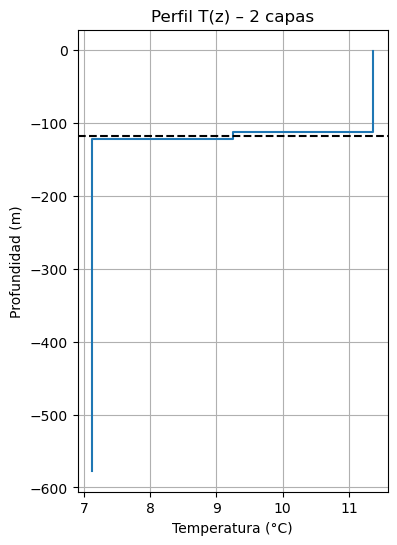

In [1]:
"""
Genera binarios MITgcm (T y S) para un perfil de DOS CAPAS
  - Capa 1: ρ1 = 997.527 kg/m³   (T1 calculada)
  - Capa 2: ρ2 = 998.377 kg/m³   (T2 calculada)
  - Interface a z*= +117.52499 m (profundidades positivas hacia abajo)
Salinidad = 0 psu (se ignora porque sBeta = 0 y saltStepping=.FALSE.)
"""

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ── CONSTANTES DEL MODELO ───────────────────────────────────────
RHO0  = 999.8       # kg m-3   (rhoNil)
ALPHA = 2.0e-4      # °C-1     (tAlpha)

# ── 1. Funciones auxiliares ─────────────────────────────────────
def rho_to_temp(rho):
    """Convierte densidad deseada a temperatura usando ρ = ρ0 - ρ0 α T."""
    return (RHO0 - rho) / (RHO0 * ALPHA)

def write_binary_3d(field_1d, nx, ny, fname):
    """Replica un vector (nz,) → (nz,ny,nx) y lo escribe big-endian float64."""
    np.tile(field_1d[:, None, None], (1, ny, nx)).astype('>f8').tofile(fname)

# ── 2. Geometría vertical (delR → RC) ───────────────────────────
delR = np.array([
    1.0,1.1,1.2,1.3,1.4,1.5,1.6,1.7,1.9,
    2.0,2.2,2.4,2.6,2.8,3.0,3.2,3.5,
    3.8,4.1,4.4,4.8,5.2,5.6,6.0,6.5,
    7.1,7.6,8.2,8.9,9.6,10.4,11.3,12.2,
    13.2,14.3,15.4,16.7,18.0,19.5,21.1,22.8,
    24.6,26.6,28.8,31.1,33.7,36.4,39.3,42.5,
    45.8])
R_faces = np.r_[0, delR.cumsum()]          # caras
RC      = 0.5 * (R_faces[:-1] + R_faces[1:])  # centros de celda (+abajo)

# ── 3. Parámetros de la capa ────────────────────────────────────
rho1, rho2     = 997.527, 998.377          # kg m-3
z_interface    = 117.52499                 # m  (positivos hacia abajo)

T1, T2 = rho_to_temp(rho1), rho_to_temp(rho2)
print(f"T1 = {T1:.2f} °C   T2 = {T2:.2f} °C")

# ── 4. Construir perfil T(z) de dos capas ───────────────────────
T = np.where(RC < z_interface, T1, T2)     # superior = RC menor

# salinidad dummy
S = np.zeros_like(T)

# ── 5. Guardar binarios ─────────────────────────────────────────
nx, ny, nz = 560, 352, len(RC)
outdir = Path("profiles_2layer")
outdir.mkdir(exist_ok=True)

write_binary_3d(T, nx, ny, outdir / f"T_2layer_{nz}z_{nx}x{ny}.bin")
write_binary_3d(S, nx, ny, outdir / f"S_dummy_{nz}z_{nx}x{ny}.bin")

print("Binarios escritos en:", outdir.resolve())

# ── 6. (Opcional) Visualización rápida ──────────────────────────
plt.figure(figsize=(4,6))
plt.step(T, -RC, where='mid')
plt.axhline(-z_interface, color='k', ls='--')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Profundidad (m)')
plt.title('Perfil T(z) – 2 capas')
plt.grid(); plt.show()


In [2]:
for Tii, ii in zip(np.round(T, decimals=1), range(len(RC))):
    print(f'{Tii},', end=" ")
    if ii!=0 and ii%8 == 0:
        print('')

11.4, 11.4, 11.4, 11.4, 11.4, 11.4, 11.4, 11.4, 11.4, 
11.4, 11.4, 11.4, 11.4, 11.4, 11.4, 11.4, 11.4, 
11.4, 11.4, 11.4, 11.4, 11.4, 11.4, 11.4, 11.4, 
11.4, 11.4, 11.4, 11.4, 11.4, 7.1, 7.1, 7.1, 
7.1, 7.1, 7.1, 7.1, 7.1, 7.1, 7.1, 7.1, 
7.1, 7.1, 7.1, 7.1, 7.1, 7.1, 7.1, 7.1, 
7.1, 

In [3]:
T_array = np.expand_dims(np.expand_dims(T, axis=1), axis=1)
T_array = T_array * np.ones((nz,ny,nx))

S_array = np.expand_dims(np.expand_dims(S, axis=1), axis=1)
S_array = S_array * np.ones((nz,ny,nx))
dt = np.dtype('>f8')  # float 64 big endian

# Save binary file
filename = "2layer_temp_%dzlev_%dx%d.bin" %(nz,nx,ny)
fileobj = open(filename,mode='wb')
T_array.astype(dt).tofile(fileobj,"")
fileobj.close()

filename = "2layer_salt_%dzlev_%dx%d.bin" %(nz,nx,ny)
fileobj = open(filename,mode='wb')
S_array.astype(dt).tofile(fileobj,"")
fileobj.close()

In [4]:
pwd

'/Volumes/Esteban_SSD/Maestría/MITgcm/verification/BayIW_Rectan_linear/input'

In [ ]:
mitgcm_path = Path("/Volumes/KINGSTON/Esteban/MITgcm/verification/BayIW_Rectan_2layer/run_expand/input")
T_file = mitgcm_path / "2layer_temp_90zlev_272x